# Week 2 - Advanced Data Visualization and Storytelling

**Dataset:** cleaned IBM Telco Customer Churn data from Week 1 (7,043 customers).

This notebook runs `src/04_visualization.py`, which builds the visual story: five
main charts that each answer one question, plus three supporting charts
(including an interactive Plotly chart saved as HTML). The code cells are taken
directly from `src/`.


In [1]:
import sys
sys.path.insert(0, "../src")  # make the project modules in src/ importable
%config InlineBackend.figure_format = 'retina'

## Week 2 - A visual story of customer churn

The story is told for a non-technical reader in five steps, each answering one
question, plus three supporting charts:

1. Where in the customer lifecycle do departures happen?
2. How does the chance of leaving change the longer a customer stays?
3. Is contract type just another way of measuring tenure?
4. Do customers who leave pay more - and is that about price or the service?
5. Which add-on services go together with staying?

Supporting: payment method within each contract type, an interactive map of
customer segments (Plotly), and a check for unusual billing records.

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from IPython.display import Image, display
from matplotlib.ticker import PercentFormatter, StrMethodFormatter
from statsmodels.stats.proportion import proportion_confint

from config import FIGURE_DIR, RESULTS_DIR, TABLE_DIR
from data_utils import ADDON_COLUMNS, CONTRACT_ORDER, load_clean_data
from plot_style import (CHURN_COLOR, GRID_COLOR, INK, MUTED_INK, ORDINAL_BLUES, RETAINED_COLOR,
                        SEQUENTIAL_CMAP, apply_style, save_figure)

apply_style()
df = load_clean_data()
overall_rate = df["churn_flag"].mean()
story = {"n_customers": len(df), "overall_churn_rate_pct": round(overall_rate * 100, 2)}
print(f"{len(df):,} customers, overall churn rate {overall_rate:.1%}")

# Tenure bands used by several charts
df["tenure_band_12"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 36, 48, 60, 72],
                              labels=["0-12", "13-24", "25-36", "37-48", "49-60", "61-72"])
six_month_edges = [-1] + list(range(6, 73, 6))
six_month_labels = ["0-6"] + [f"{lo + 1}-{lo + 6}" for lo in range(6, 72, 6)]
df["tenure_band_6"] = pd.cut(df["tenure"], bins=six_month_edges, labels=six_month_labels)


def wilson_interval(successes, totals):
    """95% Wilson confidence interval for a proportion (works well near 0 and 1)."""
    low, high = proportion_confint(successes, totals, alpha=0.05, method="wilson")
    return np.asarray(low), np.asarray(high)

7,043 customers, overall churn rate 26.5%


### Visualization 1 - Where in the customer lifecycle do departures happen?

Saved figure: outputs/figures/fig2_1_tenure_stacked_histogram.png


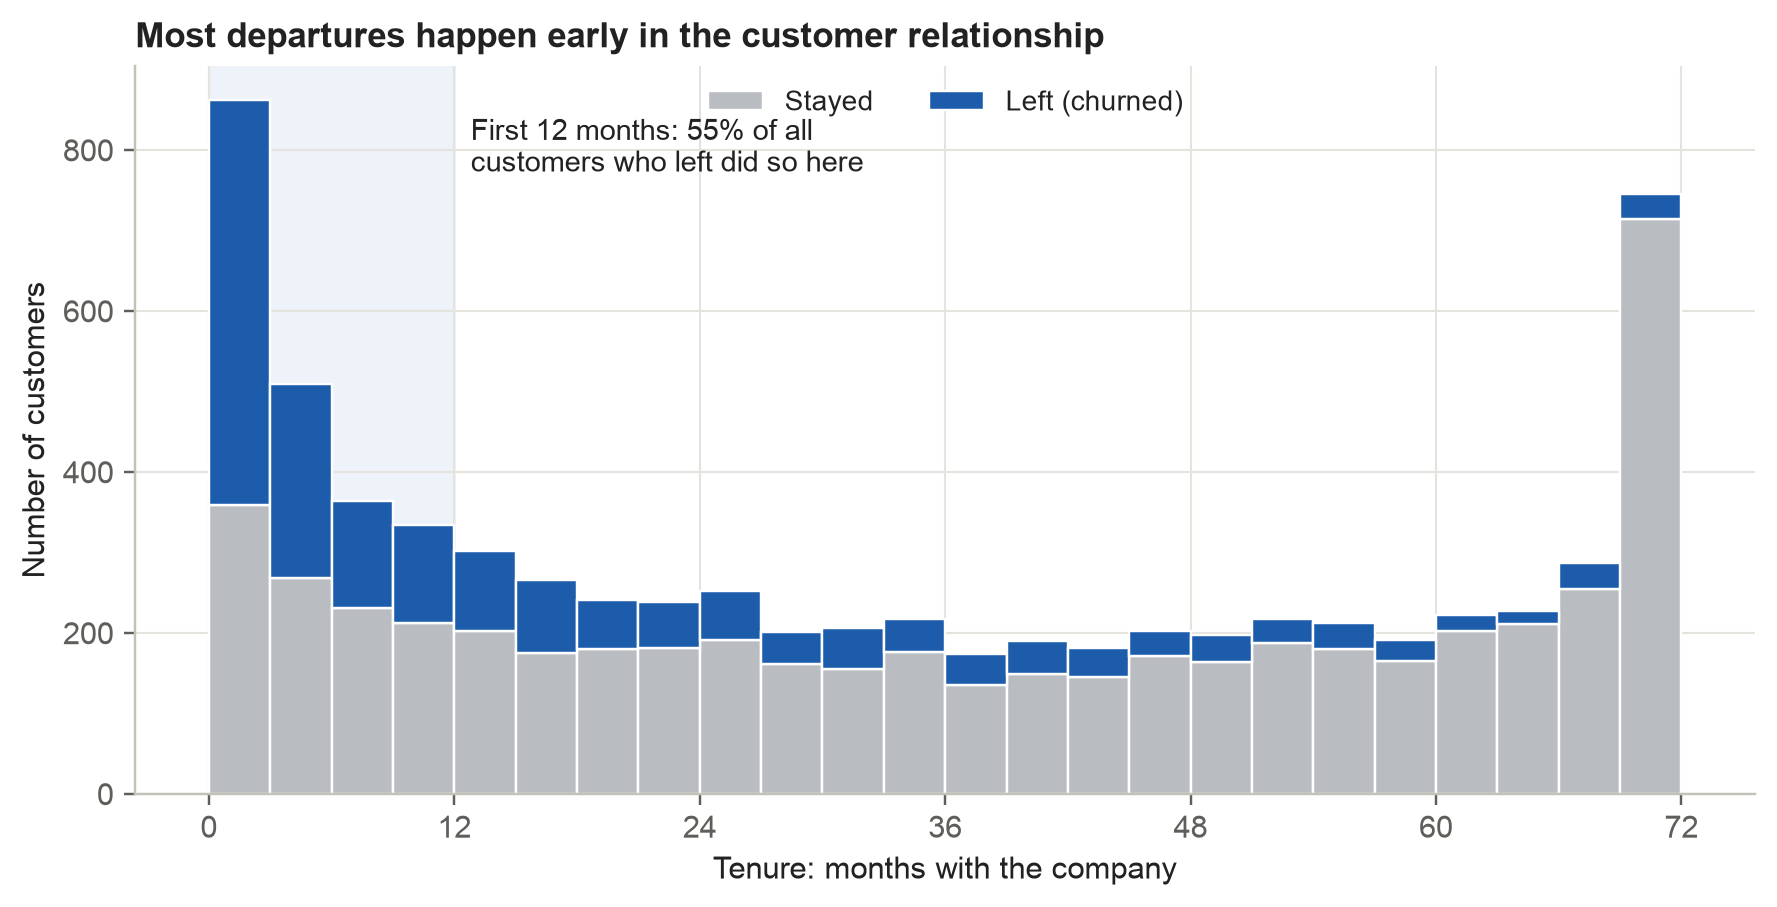

In [3]:
churned = df["Churn"] == "Yes"
first_year_share = (churned & (df["tenure"] <= 12)).sum() / churned.sum()

fig, ax = plt.subplots(figsize=(9.5, 4.3))
bins = np.arange(0, 75, 3)
ax.axvspan(0, 12, color="#eef3fa", zorder=0)
ax.hist([df.loc[~churned, "tenure"], df.loc[churned, "tenure"]], bins=bins, stacked=True,
        color=[RETAINED_COLOR, CHURN_COLOR], edgecolor="white", linewidth=0.8,
        label=["Stayed", "Left (churned)"], zorder=2)
ax.text(12.8, ax.get_ylim()[1] * 0.93,
        f"First 12 months: {first_year_share:.0%} of all\ncustomers who left did so here",
        fontsize=9.5, color=INK, va="top")
ax.set_xlabel("Tenure: months with the company")
ax.set_ylabel("Number of customers")
ax.set_xticks(range(0, 73, 12))
ax.set_title("Most departures happen early in the customer relationship")
ax.legend(loc="upper center", ncol=2)
save_figure(fig, "fig2_1_tenure_stacked_histogram.png")

story["v1"] = {
    "churned_total": int(churned.sum()),
    "churned_in_first_12_months": int((churned & (df["tenure"] <= 12)).sum()),
    "share_of_churners_in_first_12_months_pct": round(first_year_share * 100, 1),
    "customers_in_first_12_months": int((df["tenure"] <= 12).sum()),
    "customers_tenure_61_72": int((df["tenure"] > 60).sum()),
}

### Visualization 2 - How does the chance of leaving change the longer a customer stays?

,churned,customers,rate,ci_low,ci_high
tenure_band_6,,,,,
0-6,784,1481,52.9,50.4,55.5
7-12,253,705,35.9,32.4,39.5
13-18,177,548,32.3,28.5,36.3
19-24,117,476,24.6,20.9,28.6
25-30,94,431,21.8,18.2,25.9
31-36,86,401,21.4,17.7,25.7
37-42,83,379,21.9,18.0,26.3
43-48,62,383,16.2,12.8,20.2
49-54,68,420,16.2,13.0,20.0


Saved figure: outputs/figures/fig2_2_churn_rate_by_tenure.png


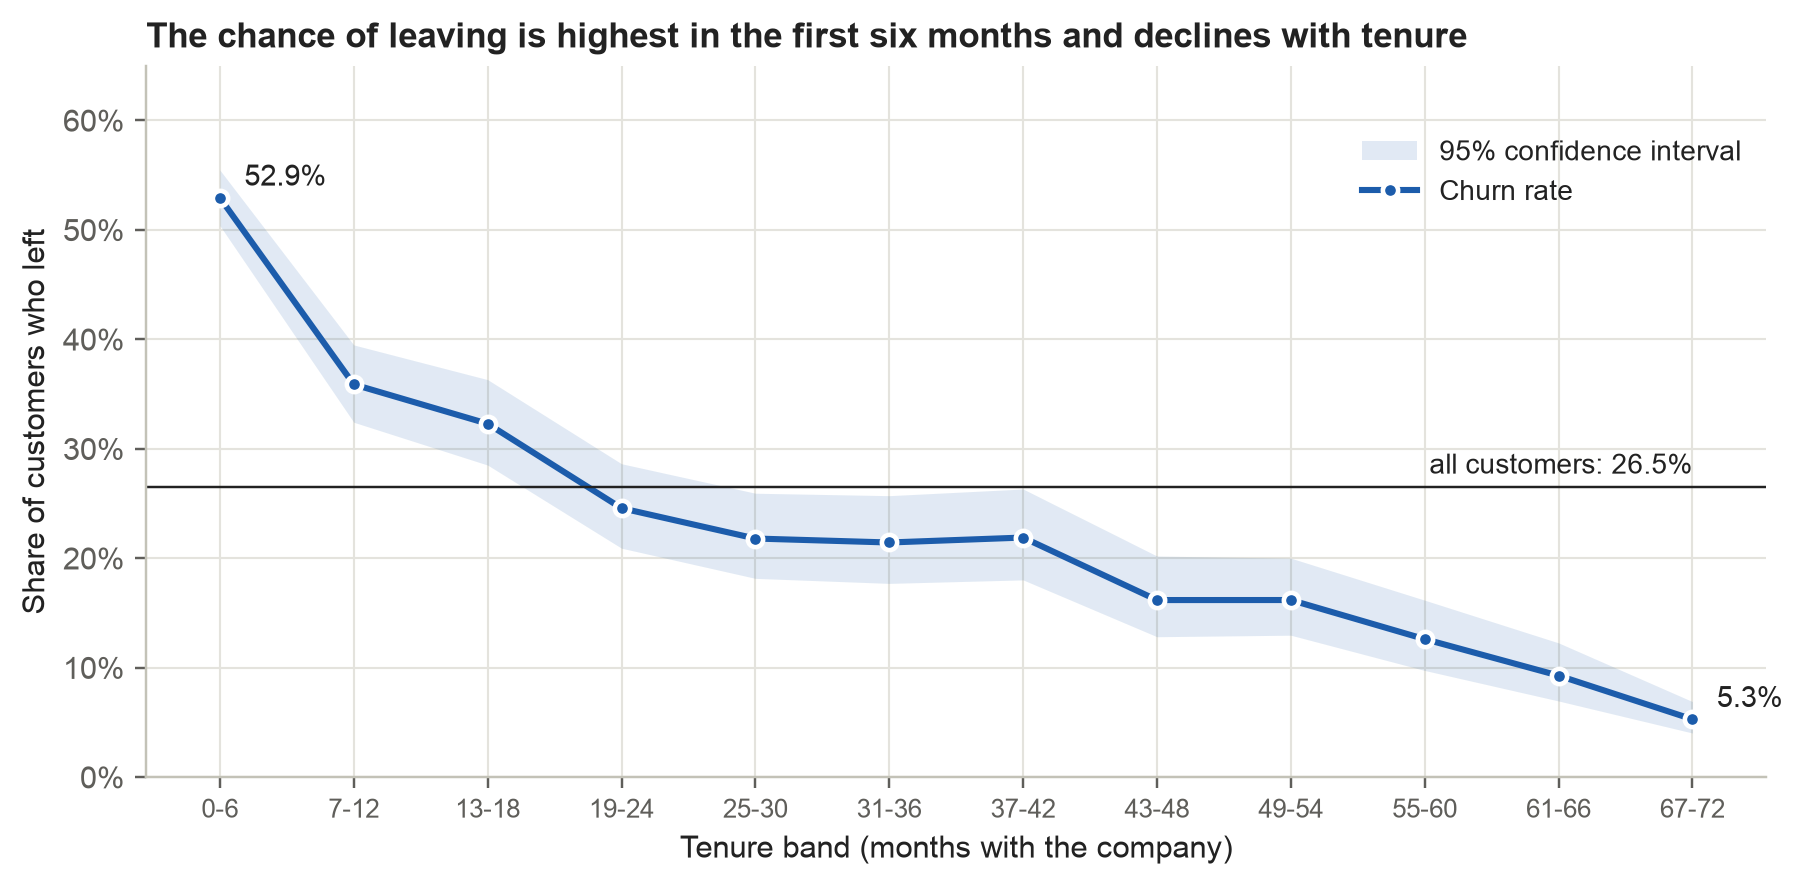

In [4]:
lifecycle = df.groupby("tenure_band_6", observed=True)["churn_flag"].agg(churned="sum", customers="size")
lifecycle["rate"] = lifecycle["churned"] / lifecycle["customers"]
lifecycle["ci_low"], lifecycle["ci_high"] = wilson_interval(lifecycle["churned"], lifecycle["customers"])
display((lifecycle.assign(rate=lifecycle["rate"] * 100, ci_low=lifecycle["ci_low"] * 100,
                          ci_high=lifecycle["ci_high"] * 100)).round(1))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
x = np.arange(len(lifecycle))
ax.fill_between(x, lifecycle["ci_low"] * 100, lifecycle["ci_high"] * 100,
                color=CHURN_COLOR, alpha=0.13, linewidth=0, label="95% confidence interval")
ax.plot(x, lifecycle["rate"] * 100, color=CHURN_COLOR, linewidth=2, marker="o",
        markersize=5, markeredgecolor="white", markeredgewidth=1.5, label="Churn rate")
ax.axhline(overall_rate * 100, color=INK, linewidth=0.8)
ax.text(len(x) - 1, overall_rate * 100 + 1.2, f"all customers: {overall_rate:.1%}",
        ha="right", fontsize=9, color=INK)
for index in (0, len(x) - 1):
    ax.annotate(f"{lifecycle['rate'].iloc[index]:.1%}", (x[index], lifecycle["rate"].iloc[index] * 100),
                xytext=(8, 4), textcoords="offset points", fontsize=9.5, color=INK)
ax.set_xticks(x)
ax.set_xticklabels(lifecycle.index, rotation=0, fontsize=8.5)
ax.set_xlabel("Tenure band (months with the company)")
ax.set_ylabel("Share of customers who left")
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_ylim(0, 65)
ax.set_title("The chance of leaving is highest in the first six months and declines with tenure")
ax.legend(loc="upper right", bbox_to_anchor=(1, 0.93))
save_figure(fig, "fig2_2_churn_rate_by_tenure.png")

lifecycle.round(4).to_csv(TABLE_DIR / "churn_rate_by_6_month_tenure_band.csv")
story["v2"] = {band: {"customers": int(row.customers), "rate_pct": round(row.rate * 100, 1),
                      "ci_low_pct": round(row.ci_low * 100, 1), "ci_high_pct": round(row.ci_high * 100, 1)}
               for band, row in lifecycle.iterrows()}

### Visualization 3 - Is contract type just another way of measuring tenure?

Month-to-month customers could churn more simply because they tend to be
newer. Comparing contract types *within* the same tenure band separates the two.

Saved figure: outputs/figures/fig2_3_contract_tenure_heatmap.png


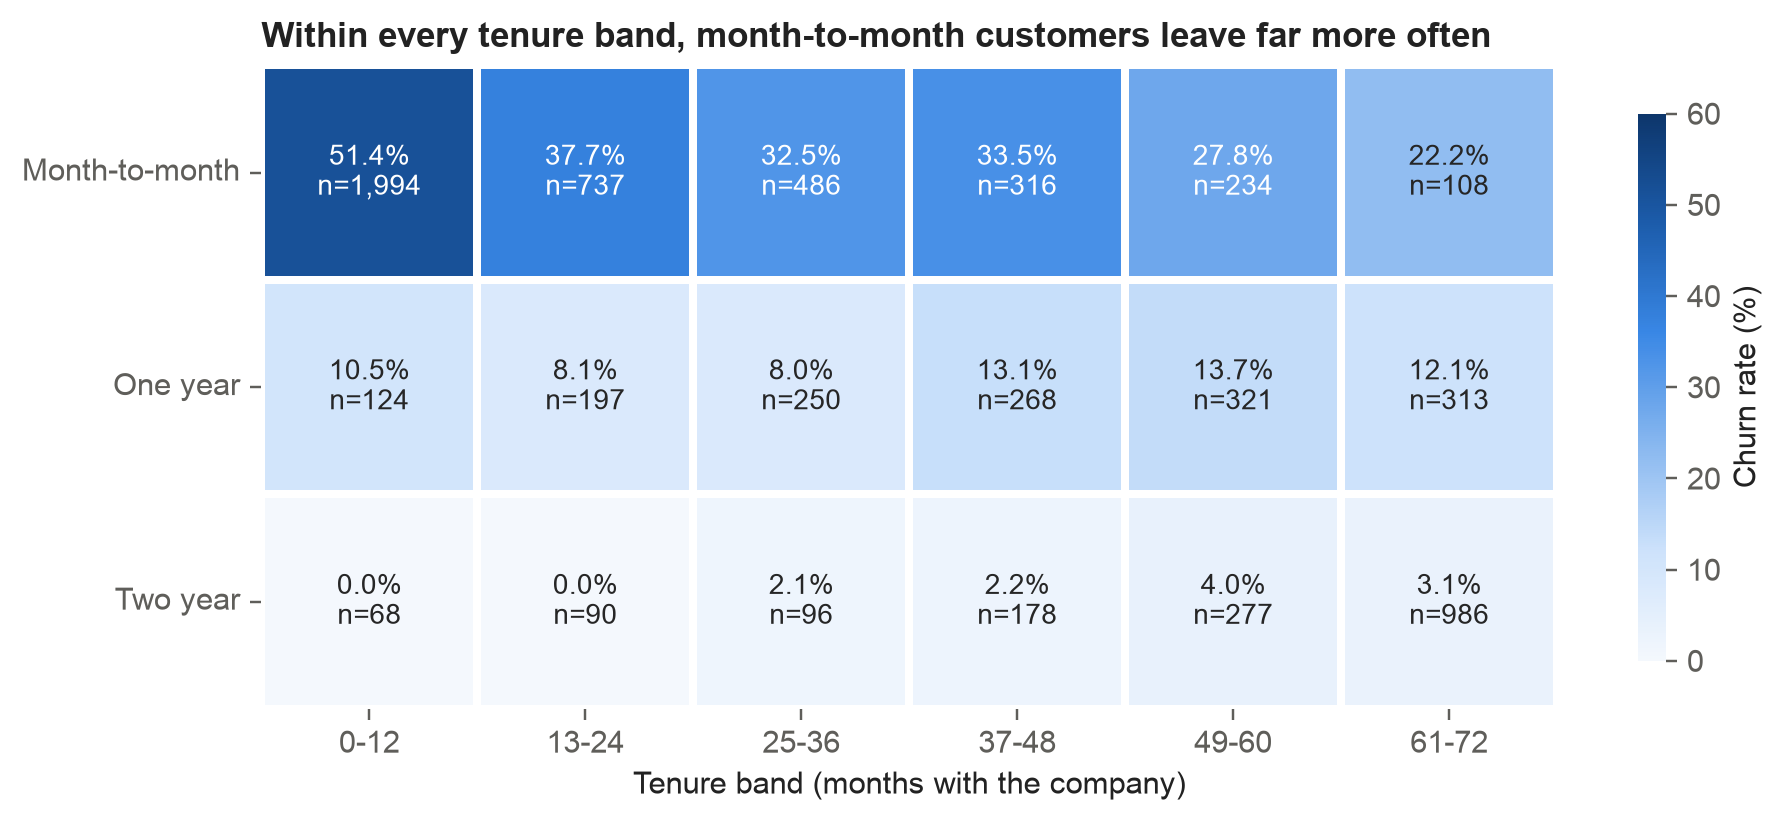

tenure_band_12,0-12,13-24,25-36,37-48,49-60,61-72
Contract,,,,,,
Month-to-month,51.4,37.7,32.5,33.5,27.8,22.2
One year,10.5,8.1,8.0,13.1,13.7,12.1
Two year,0.0,0.0,2.1,2.2,4.0,3.1


tenure_band_12,0-12,13-24,25-36,37-48,49-60,61-72
Contract,,,,,,
Month-to-month,1994,737,486,316,234,108
One year,124,197,250,268,321,313
Two year,68,90,96,178,277,986


In [5]:
rates = df.pivot_table(index="Contract", columns="tenure_band_12", values="churn_flag",
                       aggfunc="mean", observed=True) * 100
counts = df.pivot_table(index="Contract", columns="tenure_band_12", values="churn_flag",
                        aggfunc="size", observed=True)
labels = np.array([[f"{rates.iloc[i, j]:.1f}%\nn={counts.iloc[i, j]:,}" for j in range(rates.shape[1])]
                   for i in range(rates.shape[0])])

fig, ax = plt.subplots(figsize=(9.5, 3.8))
sns.heatmap(rates, annot=labels, fmt="", cmap=SEQUENTIAL_CMAP, vmin=0, vmax=60,
            linewidths=2, linecolor="white", annot_kws={"fontsize": 9},
            cbar_kws={"label": "Churn rate (%)", "shrink": 0.85}, ax=ax)
ax.set_xlabel("Tenure band (months with the company)")
ax.set_ylabel("")
ax.tick_params(axis="y", rotation=0)
ax.set_title("Within every tenure band, month-to-month customers leave far more often")
save_figure(fig, "fig2_3_contract_tenure_heatmap.png")

display(rates.round(1))
display(counts)
rates.round(2).to_csv(TABLE_DIR / "contract_by_tenure_churn_rate.csv")
counts.to_csv(TABLE_DIR / "contract_by_tenure_counts.csv")
story["v3"] = {"rates_pct": rates.round(1).to_dict("index"), "counts": counts.to_dict("index"),
               "median_tenure_by_contract": df.groupby("Contract", observed=True)["tenure"].median().to_dict()}

### Visualization 4 - Do customers who leave pay more, and is that about price or the service?

Churn,No,Yes
InternetService,,
No,20.15,20.00
DSL,59.75,49.25
Fiber optic,94.80,87.55


Saved figure: outputs/figures/fig2_4_monthly_charges_violin.png


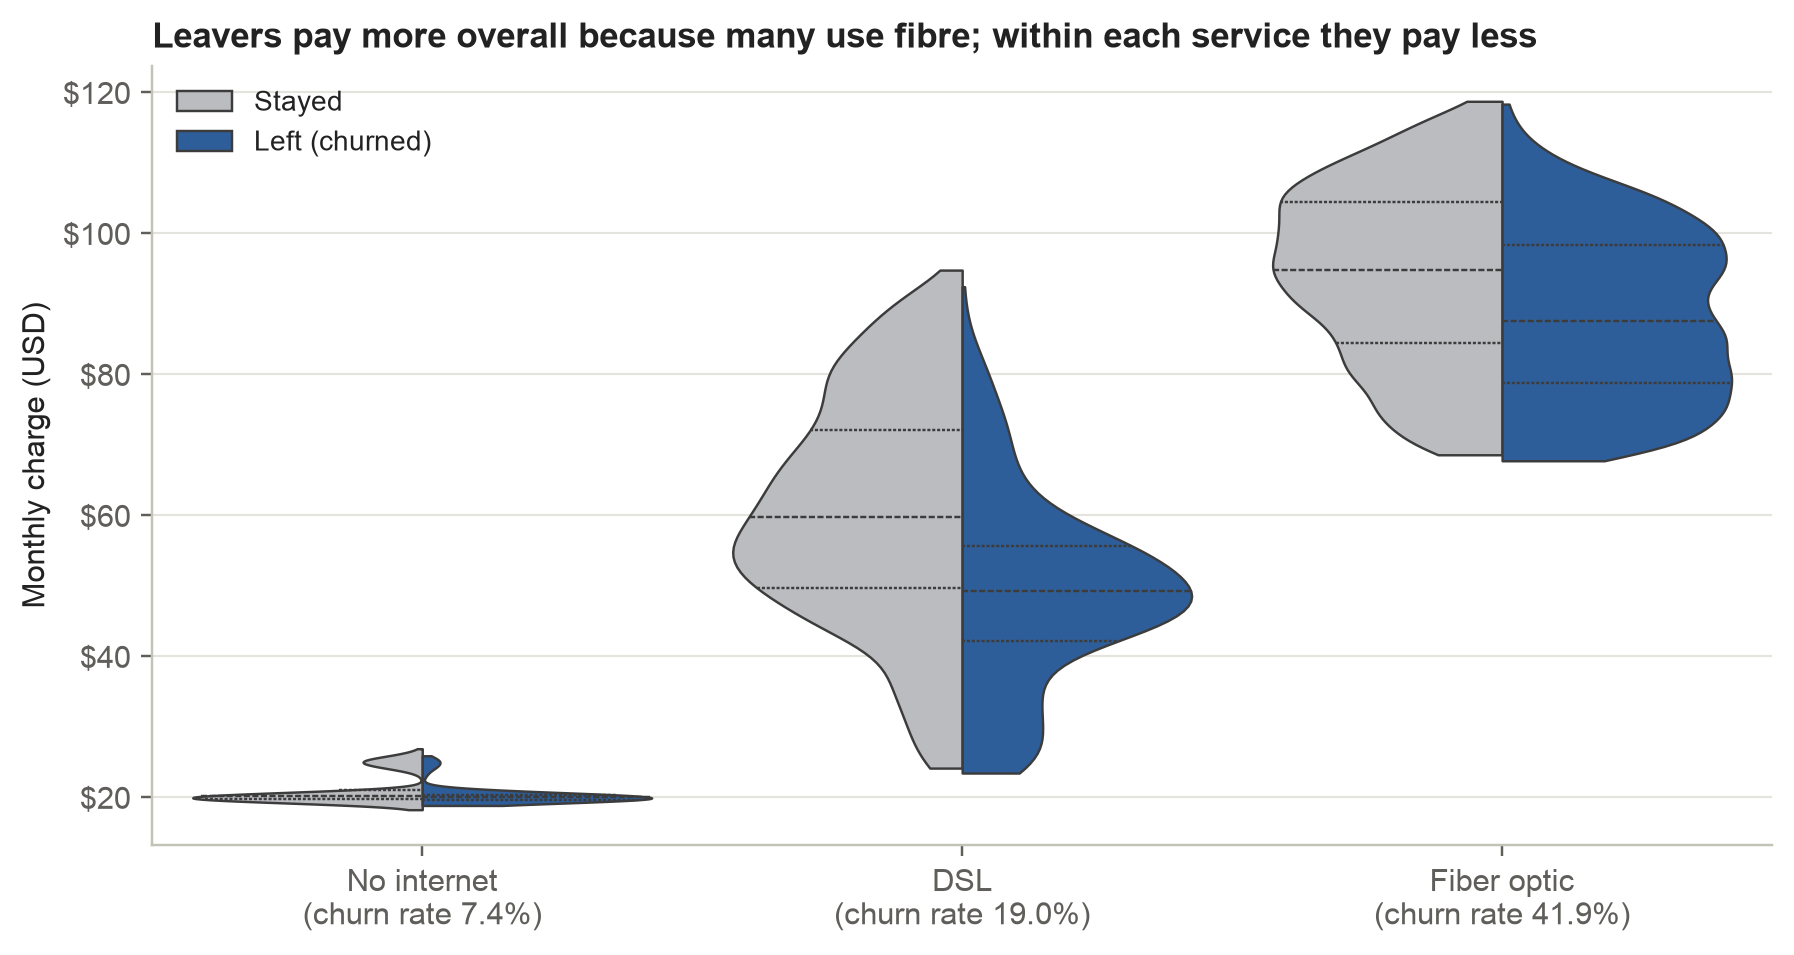

In [6]:
internet_order = ["No", "DSL", "Fiber optic"]
internet_rates = df.groupby("InternetService", observed=True)["churn_flag"].mean().reindex(internet_order)
charges = (df.groupby(["InternetService", "Churn"], observed=True)["MonthlyCharges"]
             .median().unstack().reindex(internet_order))
display(charges.round(2))

fig, ax = plt.subplots(figsize=(9.5, 4.6))
sns.violinplot(data=df, x="InternetService", y="MonthlyCharges", hue="Churn", split=True,
               order=internet_order, hue_order=["No", "Yes"], inner="quart", cut=0,
               density_norm="width", width=0.85,
               palette={"No": RETAINED_COLOR, "Yes": CHURN_COLOR}, linewidth=0.8, ax=ax)
ax.set_xticks(range(3))
ax.set_xticklabels([f"{'No internet' if s == 'No' else s}\n(churn rate {internet_rates[s]:.1%})"
                    for s in internet_order])
ax.set_xlabel("")
ax.set_ylabel("Monthly charge (USD)")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Stayed", "Left (churned)"], loc="upper left")
ax.set_title("Leavers pay more overall because many use fibre; within each service they pay less")
save_figure(fig, "fig2_4_monthly_charges_violin.png")

charges.round(2).to_csv(TABLE_DIR / "median_monthly_charge_by_internet_and_churn.csv")
story["v4"] = {"internet_churn_rate_pct": (internet_rates * 100).round(1).to_dict(),
               "median_charge": {s: {"stayed": round(float(charges.loc[s, "No"]), 2),
                                     "left": round(float(charges.loc[s, "Yes"]), 2)} for s in internet_order},
               "internet_customers": df["InternetService"].value_counts().to_dict()}

### Visualization 5 - Which add-on services go together with staying?

Add-ons are only available with internet service, so this comparison uses
internet customers only. Otherwise the "no internet" group would distort it.

,add_on,rate_with,n_with,rate_without,n_without,gap
4,StreamingTV,30.1,2707,33.5,2810,3.5
5,StreamingMovies,29.9,2732,33.7,2785,3.7
2,DeviceProtection,22.5,2422,39.1,3095,16.6
1,OnlineBackup,21.5,2429,39.9,3088,18.4
3,TechSupport,15.2,2044,41.6,3473,26.5
0,OnlineSecurity,14.6,2019,41.8,3498,27.2


Saved figure: outputs/figures/fig2_5_addon_services_dumbbell.png


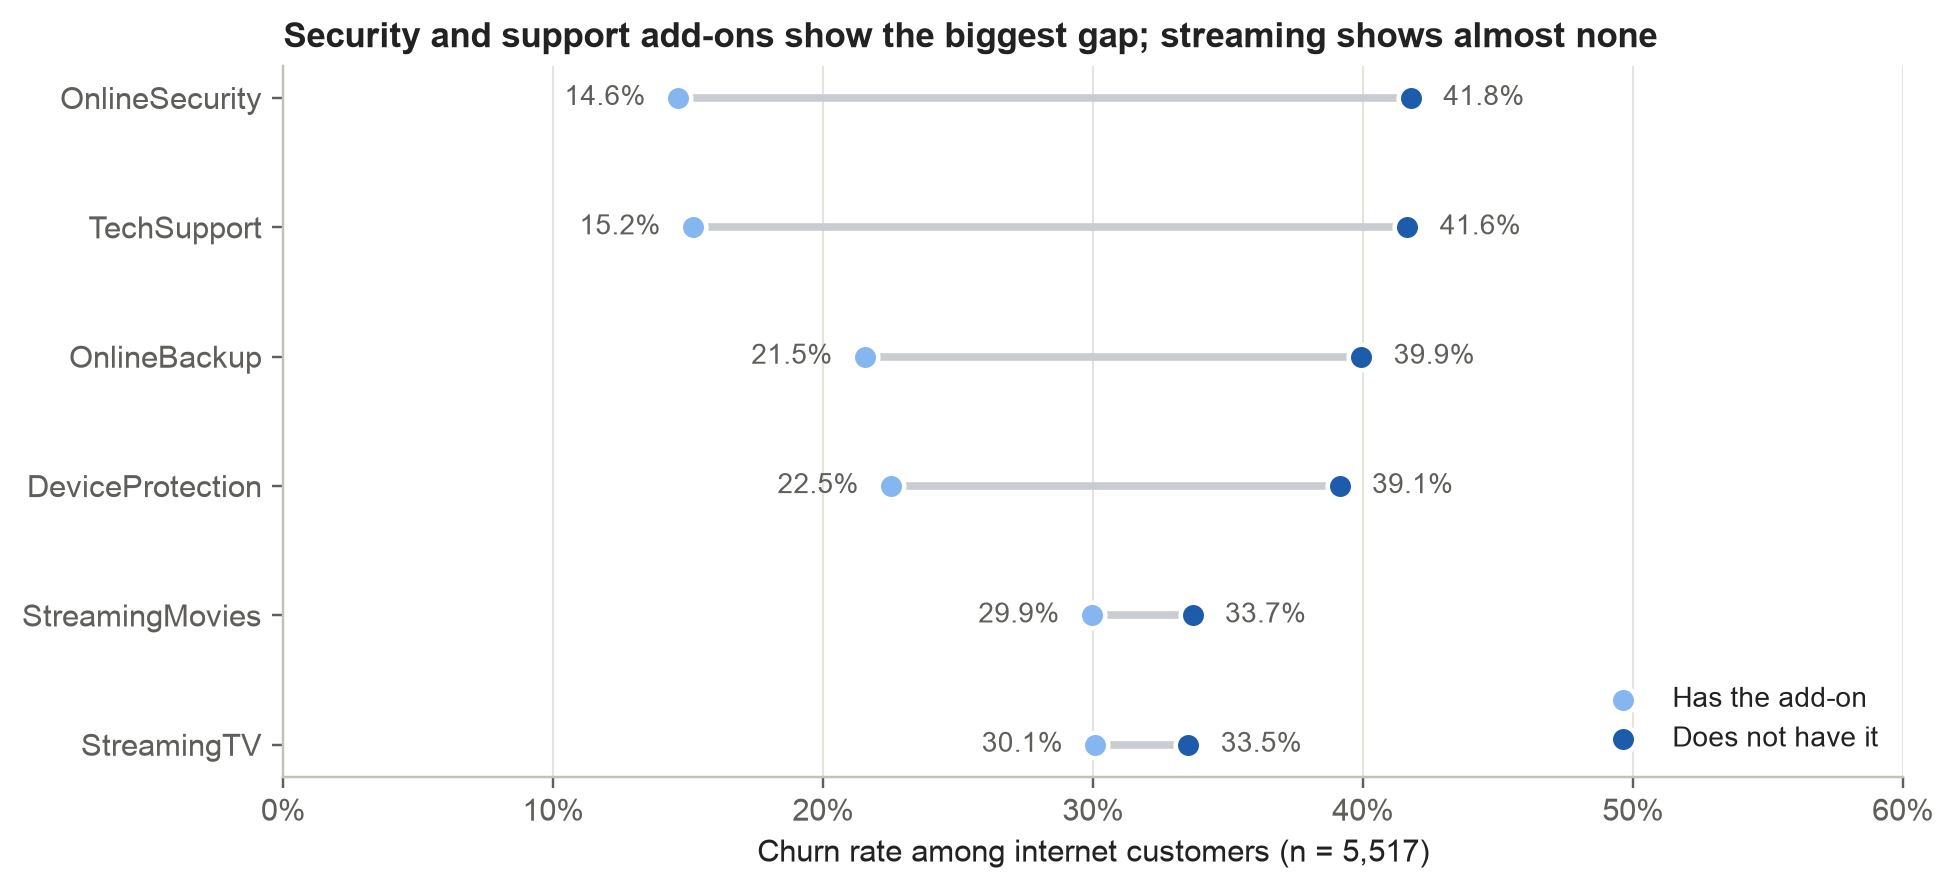

In [7]:
internet_customers = df[df["InternetService"] != "No"]
addon_rows = []
for column in ADDON_COLUMNS:
    grouped = internet_customers.groupby(column, observed=True)["churn_flag"].agg(["mean", "size"])
    addon_rows.append({"add_on": column,
                       "rate_with": grouped.loc["Yes", "mean"] * 100, "n_with": int(grouped.loc["Yes", "size"]),
                       "rate_without": grouped.loc["No", "mean"] * 100, "n_without": int(grouped.loc["No", "size"])})
addons = pd.DataFrame(addon_rows)
addons["gap"] = addons["rate_without"] - addons["rate_with"]
addons = addons.sort_values("gap")
display(addons.round(1))

fig, ax = plt.subplots(figsize=(9.5, 4.2))
y = np.arange(len(addons))
ax.hlines(y, addons["rate_with"], addons["rate_without"], color="#c9ccd1", linewidth=2.5, zorder=1)
ax.scatter(addons["rate_with"], y, s=70, color=ORDINAL_BLUES[0], edgecolor="white",
           linewidth=1.5, zorder=3, label="Has the add-on")
ax.scatter(addons["rate_without"], y, s=70, color=CHURN_COLOR, edgecolor="white",
           linewidth=1.5, zorder=3, label="Does not have it")
for position, (_, row) in zip(y, addons.iterrows()):
    ax.text(row["rate_with"] - 1.2, position, f"{row['rate_with']:.1f}%", ha="right", va="center",
            fontsize=9, color=MUTED_INK)
    ax.text(row["rate_without"] + 1.2, position, f"{row['rate_without']:.1f}%", ha="left", va="center",
            fontsize=9, color=MUTED_INK)
ax.set_yticks(y)
ax.set_yticklabels(addons["add_on"])
ax.set_xlim(0, 60)
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlabel(f"Churn rate among internet customers (n = {len(internet_customers):,})")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right")
ax.set_title("Security and support add-ons show the biggest gap; streaming shows almost none")
save_figure(fig, "fig2_5_addon_services_dumbbell.png")

addons.round(2).to_csv(TABLE_DIR / "addon_churn_rates_internet_customers.csv", index=False)
story["v5"] = {"internet_customers": len(internet_customers),
               "addons": addons.round(1).set_index("add_on").to_dict("index")}

### Additional 1 - Is the payment-method pattern just a contract pattern in disguise?

Saved figure: outputs/figures/fig2_6_payment_within_contract.png


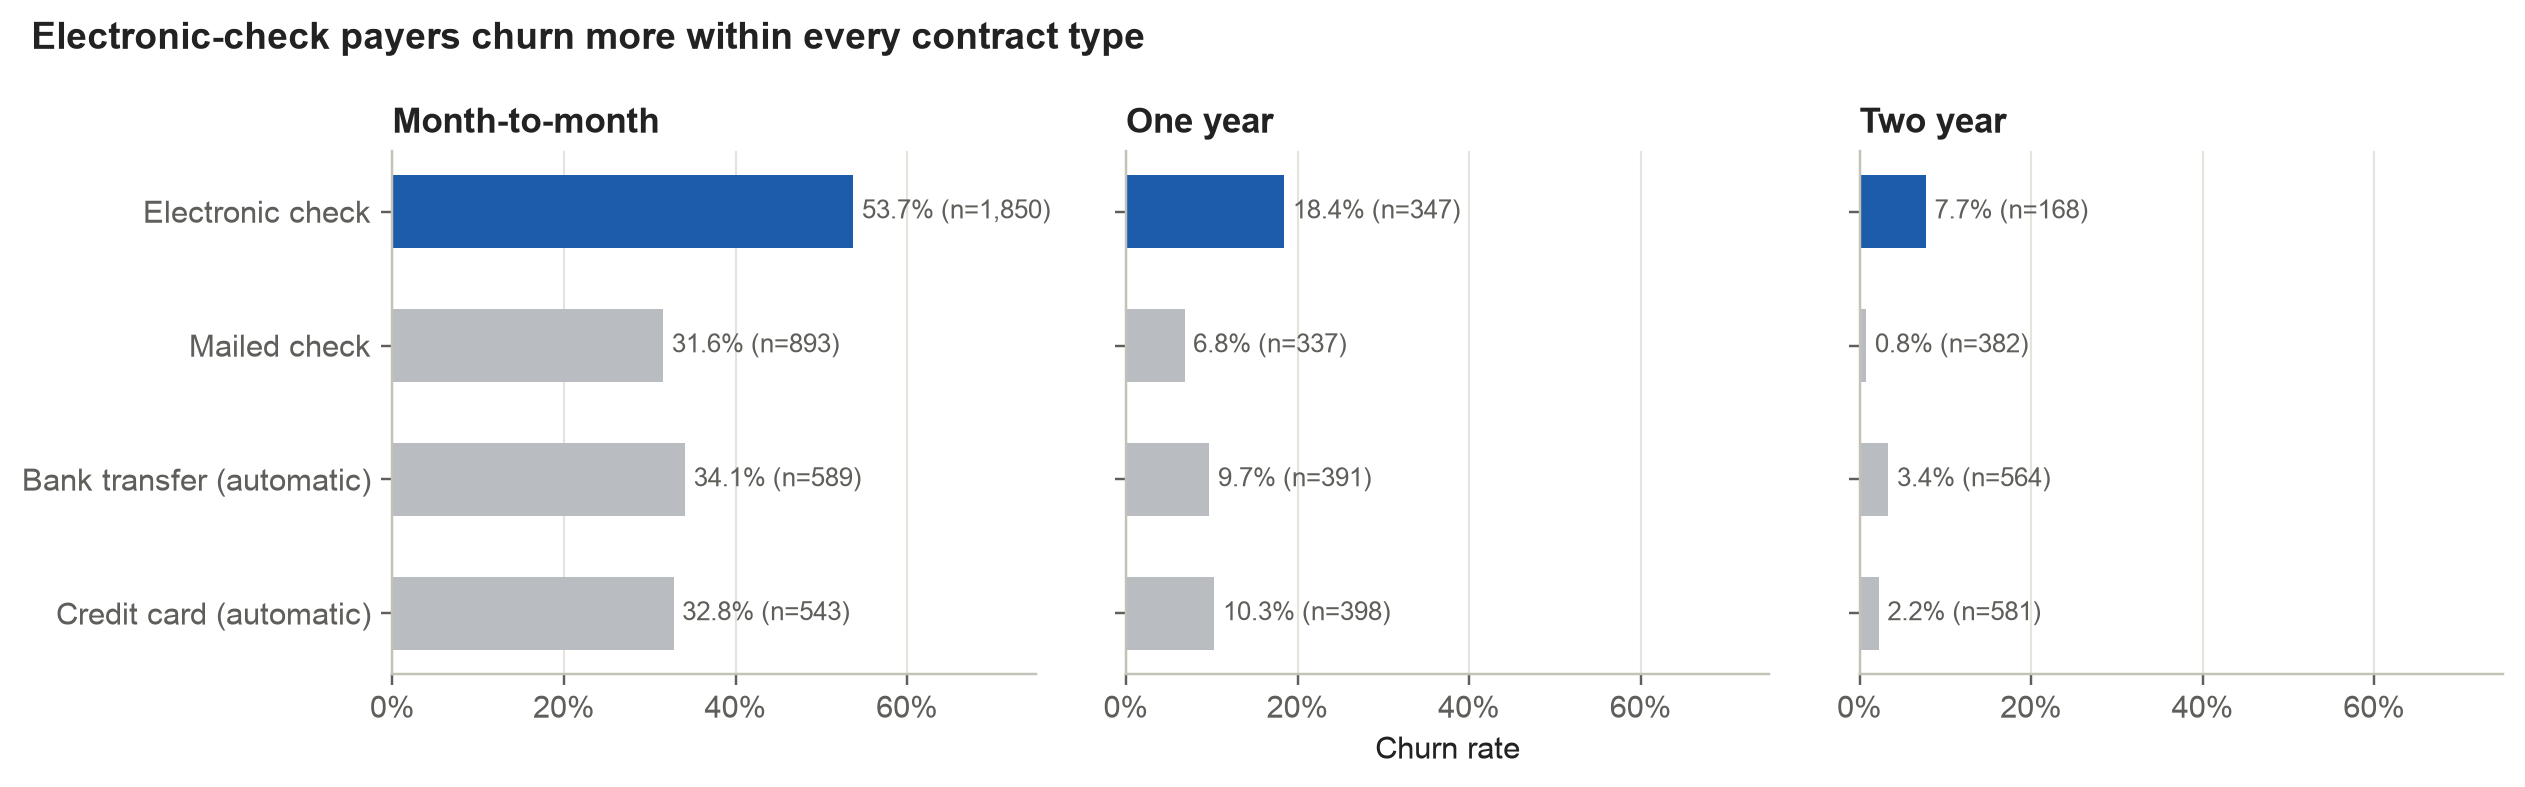

In [8]:
payment_order = ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]
payment = (df.groupby(["Contract", "PaymentMethod"], observed=True)["churn_flag"]
             .agg(rate="mean", customers="size").reset_index())
payment["rate"] *= 100

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.6), sharey=True)
for ax, contract in zip(axes, CONTRACT_ORDER):
    subset = payment[payment["Contract"] == contract].set_index("PaymentMethod").reindex(payment_order)
    colours = [CHURN_COLOR if method == "Electronic check" else RETAINED_COLOR for method in payment_order]
    ax.barh(range(4), subset["rate"], height=0.55, color=colours)
    for position, (rate, n) in enumerate(zip(subset["rate"], subset["customers"])):
        ax.text(rate + 1, position, f"{rate:.1f}% (n={n:,})", va="center", fontsize=8.5, color=MUTED_INK)
    ax.set_title(contract)
    ax.set_xlim(0, 75)
    ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(payment_order)
axes[0].invert_yaxis()
axes[1].set_xlabel("Churn rate")
fig.suptitle("Electronic-check payers churn more within every contract type", x=0.01, ha="left",
             fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig2_6_payment_within_contract.png")

payment.round(2).to_csv(TABLE_DIR / "churn_by_contract_and_payment.csv", index=False)
story["v6"] = {contract: payment[payment["Contract"] == contract].set_index("PaymentMethod")
               [["rate", "customers"]].round(1).to_dict("index") for contract in CONTRACT_ORDER}

### Additional 2 - Where do the highest-risk customer groups sit? (interactive, Plotly)

Each bubble is one combination of contract type, internet service and payment
method. The interactive version (hover for details) is saved as HTML.

36 segments; largest source of churn: Month-to-month | Fiber optic | Electronic check (789 of 1869 churners, 42.2%)


Saved outputs/figures/fig2_7_segment_risk_map.html (interactive) and .png (static)


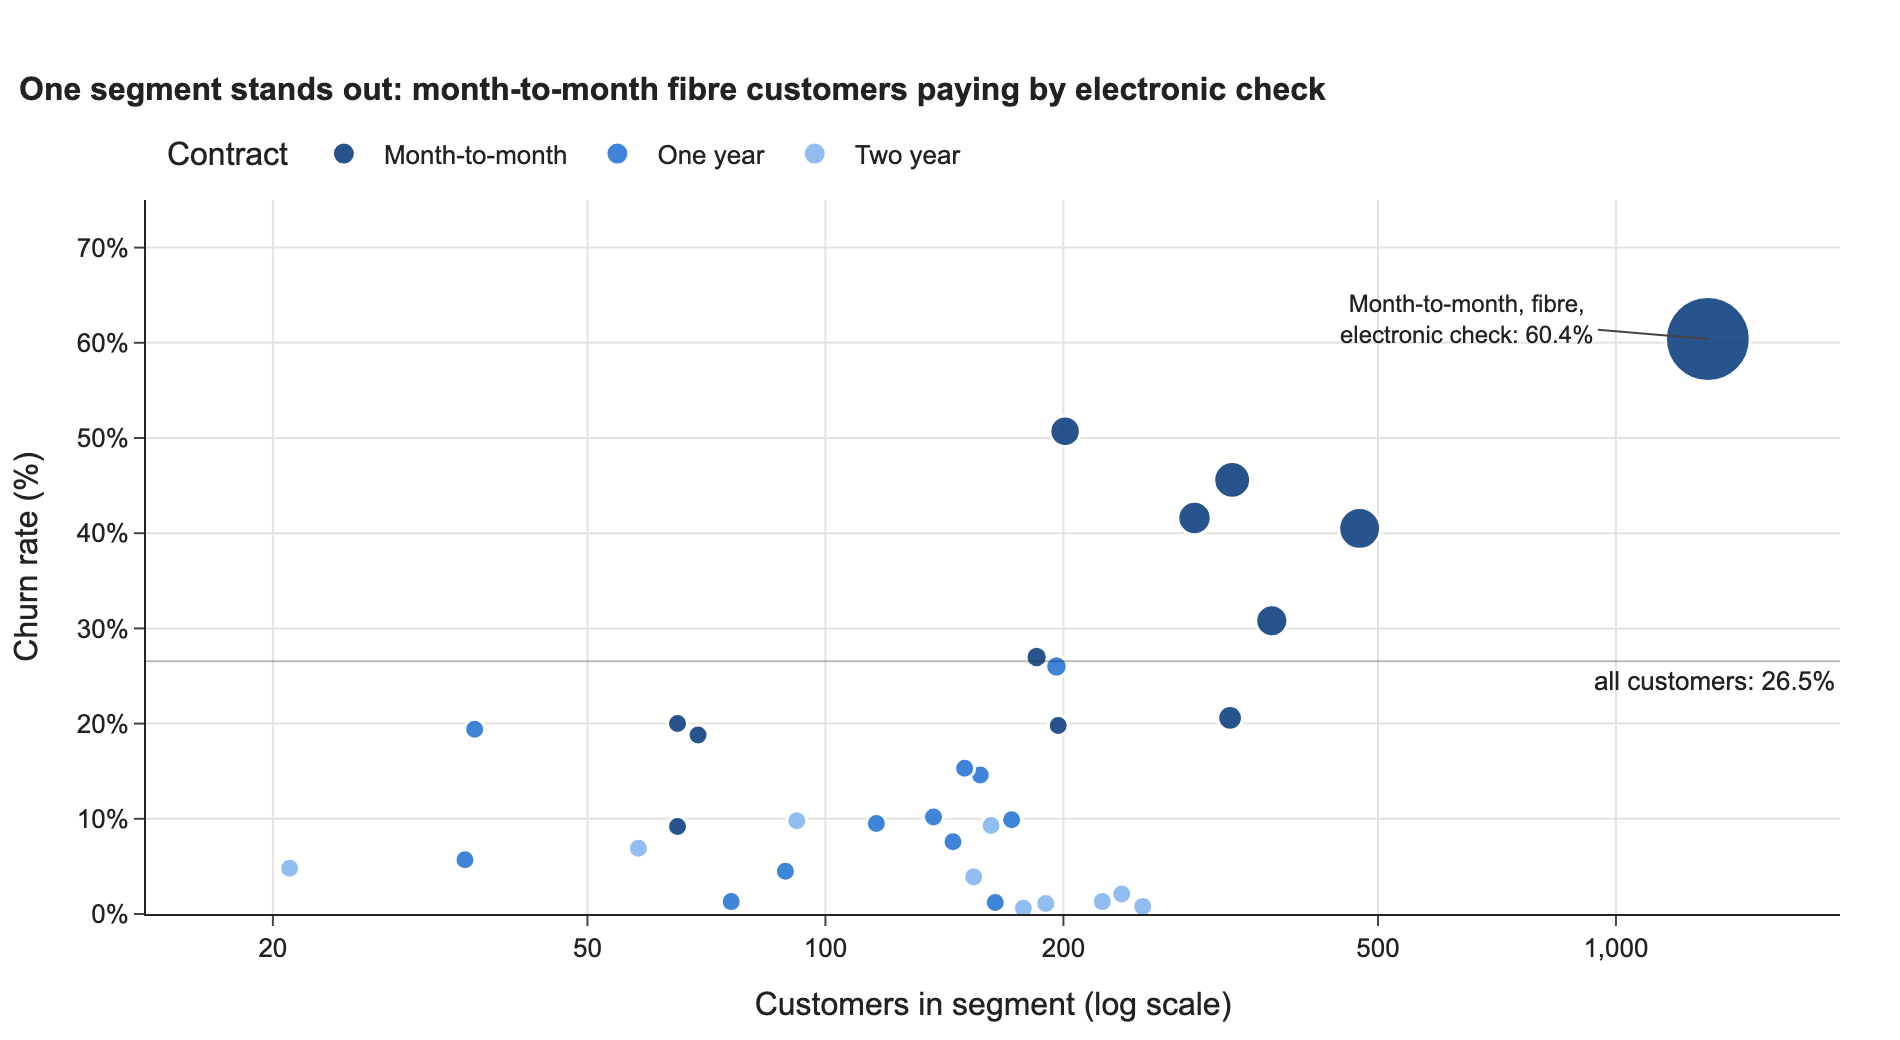

In [9]:
segments = (df.groupby(["Contract", "InternetService", "PaymentMethod"], observed=True)["churn_flag"]
              .agg(customers="size", churned="sum").reset_index())
segments["churn_rate"] = (segments["churned"] / segments["customers"] * 100).round(1)
segments["segment"] = (segments["Contract"].astype(str) + " | " + segments["InternetService"].astype(str)
                       + " | " + segments["PaymentMethod"].astype(str))
segments = segments.sort_values("churned", ascending=False).reset_index(drop=True)
top_segment = segments.iloc[0]
share_of_churn = top_segment["churned"] / segments["churned"].sum()
print(f"{len(segments)} segments; largest source of churn: {top_segment['segment']} "
      f"({top_segment['churned']} of {segments['churned'].sum()} churners, {share_of_churn:.1%})")

fig = px.scatter(segments, x="customers", y="churn_rate", size="churned", color="Contract",
                 category_orders={"Contract": CONTRACT_ORDER},
                 color_discrete_sequence=[ORDINAL_BLUES[2], ORDINAL_BLUES[1], ORDINAL_BLUES[0]],
                 hover_name="segment", size_max=30, log_x=True,
                 hover_data={"customers": ":,", "churned": ":,", "churn_rate": ":.1f", "Contract": False},
                 labels={"customers": "Customers in segment (log scale)",
                         "churn_rate": "Churn rate (%)", "churned": "Customers who left"})
fig.add_hline(y=overall_rate * 100, line_width=1, line_color=INK,
              annotation_text=f"all customers: {overall_rate:.1%}", annotation_position="bottom right")
fig.add_annotation(x=np.log10(top_segment["customers"]), y=top_segment["churn_rate"],
                   text=f"Month-to-month, fibre,<br>electronic check: {top_segment['churn_rate']:.1f}%",
                   showarrow=True, arrowhead=0, ax=-120, ay=-10, font=dict(size=12, color=INK))
fig.update_traces(marker=dict(line=dict(width=1.5, color="white"), opacity=0.9, sizemin=5))
fig.update_layout(template="simple_white", width=950, height=520, font=dict(family="Arial", size=13, color=INK),
                  title=dict(text="<b>One segment stands out: month-to-month fibre customers paying by electronic check</b>",
                             x=0.01, font=dict(size=16)),
                  legend=dict(title="Contract", orientation="h", y=1.02, x=0.01, yanchor="bottom"),
                  margin=dict(l=70, r=30, t=100, b=60))
fig.update_yaxes(range=[0, 75], gridcolor=GRID_COLOR, showgrid=True, ticksuffix="%")
fig.update_xaxes(gridcolor=GRID_COLOR, showgrid=True, tickvals=[20, 50, 100, 200, 500, 1000, 2000],
                 ticktext=["20", "50", "100", "200", "500", "1,000", "2,000"], minor=dict(showgrid=False))
# A fixed div_id keeps the HTML file identical between runs (Plotly otherwise generates a random id)
fig.write_html(FIGURE_DIR / "fig2_7_segment_risk_map.html", include_plotlyjs="cdn", div_id="fig2-7-segment-risk-map")
fig.write_image(FIGURE_DIR / "fig2_7_segment_risk_map.png", scale=2)
print("Saved outputs/figures/fig2_7_segment_risk_map.html (interactive) and .png (static)")
display(Image(filename=str(FIGURE_DIR / "fig2_7_segment_risk_map.png"), width=800))

segments.to_csv(TABLE_DIR / "segment_churn_rates.csv", index=False)
story["v7"] = {"n_segments": len(segments), "top_segment": top_segment["segment"],
               "top_segment_customers": int(top_segment["customers"]),
               "top_segment_churned": int(top_segment["churned"]),
               "top_segment_rate_pct": float(top_segment["churn_rate"]),
               "top_segment_share_of_all_churn_pct": round(share_of_churn * 100, 1),
               "top5": segments.head(5)[["segment", "customers", "churned", "churn_rate"]].to_dict("records")}

### Additional 3 - Are there unusual billing records that could distort the story?

Saved figure: outputs/figures/fig2_8_billing_consistency.png


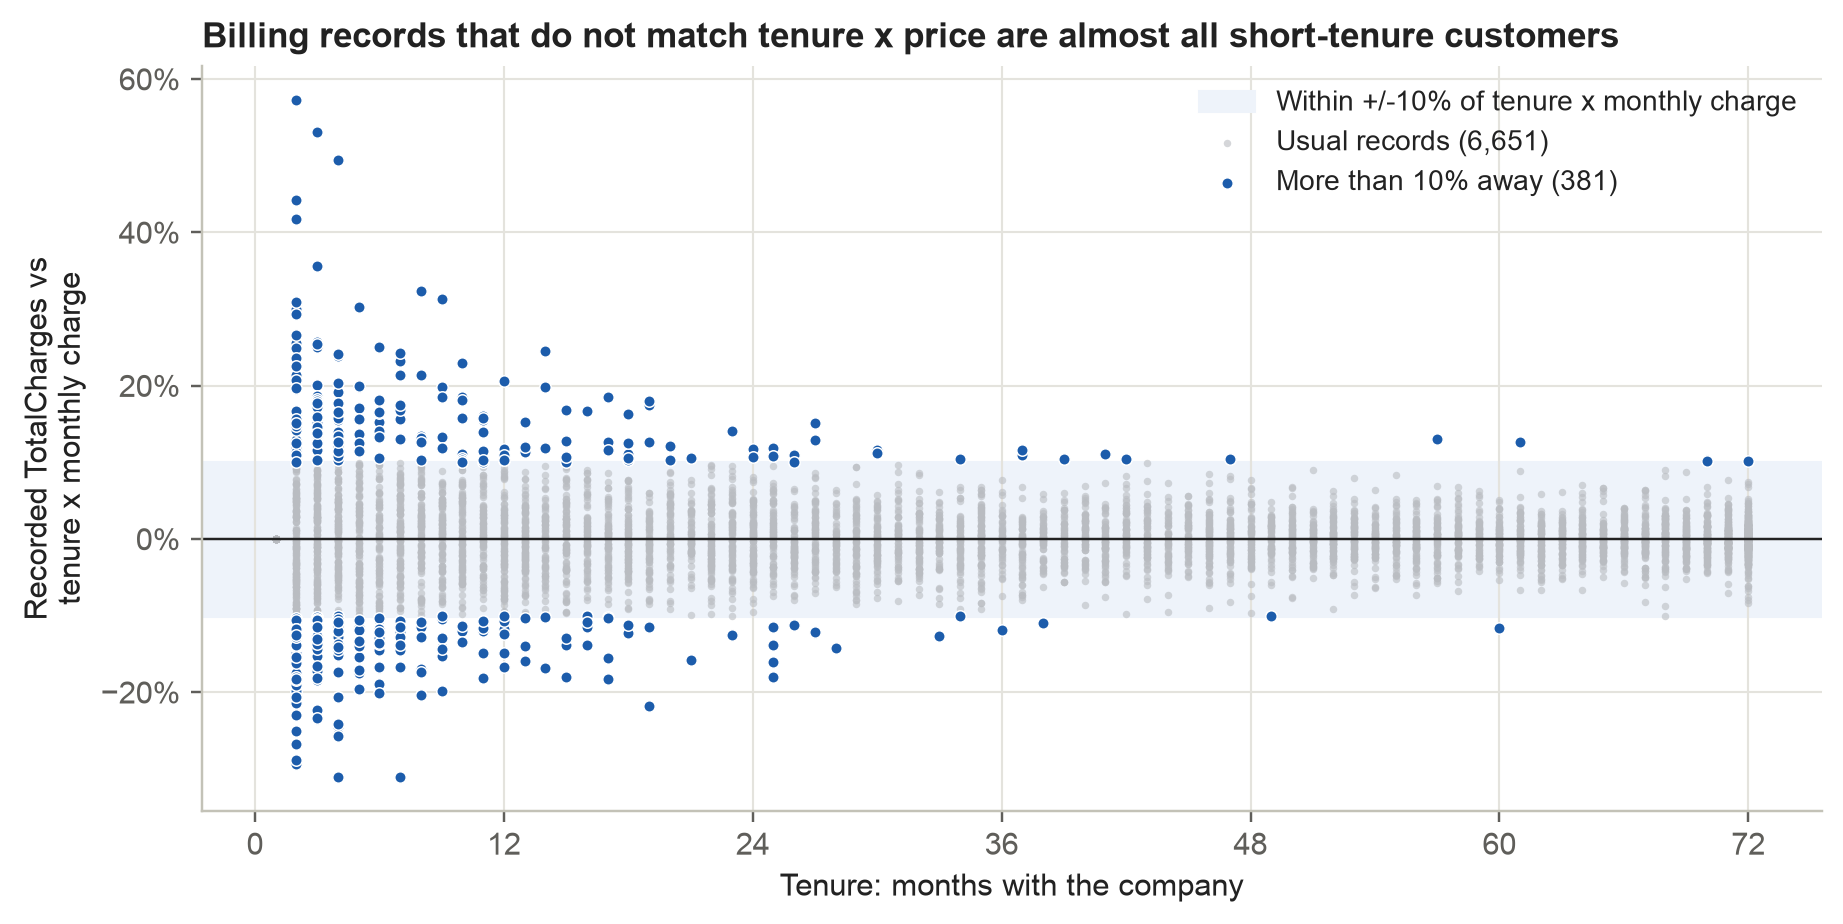

tenure         churn_flag       
        median    mean     median   mean
unusual                                 
False     31.0  33.721        0.0  0.265
True       6.0   9.740        0.0  0.286

In [10]:
billed = df[df["tenure"] > 0].copy()
billed["expected_total"] = billed["tenure"] * billed["MonthlyCharges"]
billed["deviation"] = billed["TotalCharges"] / billed["expected_total"] - 1
unusual = billed["deviation"].abs() > 0.10

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.axhspan(-10, 10, color="#eef3fa", zorder=0, label="Within +/-10% of tenure x monthly charge")
ax.scatter(billed.loc[~unusual, "tenure"], billed.loc[~unusual, "deviation"] * 100, s=6,
           color=RETAINED_COLOR, alpha=0.6, linewidths=0, zorder=2,
           label=f"Usual records ({(~unusual).sum():,})")
ax.scatter(billed.loc[unusual, "tenure"], billed.loc[unusual, "deviation"] * 100, s=14,
           color=CHURN_COLOR, edgecolor="white", linewidth=0.5, zorder=3,
           label=f"More than 10% away ({unusual.sum():,})")
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_xlabel("Tenure: months with the company")
ax.set_ylabel("Recorded TotalCharges vs\ntenure x monthly charge")
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xticks(range(0, 73, 12))
ax.legend(loc="upper right")
ax.set_title("Billing records that do not match tenure x price are almost all short-tenure customers")
save_figure(fig, "fig2_8_billing_consistency.png")

comparison = billed.groupby(unusual.rename("unusual"))[["tenure", "churn_flag"]].agg(["median", "mean"]).round(3)
display(comparison)
story["v8"] = {"billed_customers": len(billed), "unusual": int(unusual.sum()),
               "unusual_median_tenure": float(billed.loc[unusual, "tenure"].median()),
               "usual_median_tenure": float(billed.loc[~unusual, "tenure"].median()),
               "unusual_churn_rate_pct": round(billed.loc[unusual, "churn_flag"].mean() * 100, 1),
               "usual_churn_rate_pct": round(billed.loc[~unusual, "churn_flag"].mean() * 100, 1)}

In [11]:
with open(RESULTS_DIR / "visual_story_summary.json", "w") as f:
    json.dump(story, f, indent=2, default=str)
print("Saved outputs/results/visual_story_summary.json")

Saved outputs/results/visual_story_summary.json
